<a href="https://colab.research.google.com/github/sitong0509/Beyond-Administrative-Boundaries-Measuring-Ethnic-Disparities-in-Violent-Crime-Exposure-in-London/blob/main/2_crime_and_ethnic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 2.0 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon, MultiPolygon
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from scipy.stats import gaussian_kde
from matplotlib.patches import PathPatch
from matplotlib.path import Path
import osmnx as ox
import networkx as nx
import matplotlib.lines as mlines
import seaborn as sns

# 2 data

In [ ]:
crime_folder = '/content/drive/MyDrive/RQ2/github/Crime_data_count_2024.csv'
crime_df = pd.read_csv(crime_folder)
crime_df

,Latitude,Longitude,Month,Anti-social behaviour,Bicycle theft,Burglary,Criminal damage and arson,Drugs,Other crime,Other theft,Possession of weapons,Public order,Robbery,Shoplifting,Theft from the person,Vehicle crime,Violence and sexual offences,Total_count
0,49.915575,-6.318140,2024-01,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
1,49.966031,-5.196327,2024-01,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
2,49.992494,-5.183375,2024-01,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
3,50.015685,-5.255357,2024-01,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,50.020717,-5.100670,2024-01,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2520873,55.779628,-2.009269,2024-12,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
2520874,55.781110,-2.010975,2024-12,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
2520875,55.782638,-2.008504,2024-12,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
2520876,55.783186,-2.015026,2024-12,0,0,0,0,0,0,0,0,0,0,3,0,0,0,3


In [ ]:
crime_grouped = crime_df.groupby(['Latitude', 'Longitude'], as_index=False).sum(numeric_only=True)
crime_grouped

,Latitude,Longitude,Anti-social behaviour,Bicycle theft,Burglary,Criminal damage and arson,Drugs,Other crime,Other theft,Possession of weapons,Public order,Robbery,Shoplifting,Theft from the person,Vehicle crime,Violence and sexual offences,Total_count
0,49.892904,-6.345182,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2
1,49.913001,-6.307779,0,0,0,0,0,2,0,0,0,0,0,0,0,0,2
2,49.913415,-6.298563,1,0,0,0,0,0,1,0,0,0,0,1,2,1,6
3,49.913776,-6.313283,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
4,49.913919,-6.308739,0,0,0,1,0,0,0,0,0,0,0,0,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590382,55.787185,-2.014039,0,0,2,0,0,0,1,0,1,0,0,0,0,0,4
590383,55.788274,-2.042360,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
590384,55.789709,-2.014901,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
590385,55.790238,-2.019717,1,0,0,0,0,0,0,0,0,0,0,0,1,0,2


In [ ]:
crime_grouped['geometry'] = crime_grouped.apply(lambda row: Point(row['Longitude'], row['Latitude']), axis=1)

In [ ]:
gdf_crime = gpd.GeoDataFrame(crime_grouped, geometry='geometry', crs='EPSG:4326')
gdf_crime

,Latitude,Longitude,Anti-social behaviour,Bicycle theft,Burglary,Criminal damage and arson,Drugs,Other crime,Other theft,Possession of weapons,Public order,Robbery,Shoplifting,Theft from the person,Vehicle crime,Violence and sexual offences,Total_count,geometry
0,49.892904,-6.345182,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,POINT (-6.34518 49.8929)
1,49.913001,-6.307779,0,0,0,0,0,2,0,0,0,0,0,0,0,0,2,POINT (-6.30778 49.913)
2,49.913415,-6.298563,1,0,0,0,0,0,1,0,0,0,0,1,2,1,6,POINT (-6.29856 49.91342)
3,49.913776,-6.313283,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,POINT (-6.31328 49.91378)
4,49.913919,-6.308739,0,0,0,1,0,0,0,0,0,0,0,0,0,1,2,POINT (-6.30874 49.91392)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590382,55.787185,-2.014039,0,0,2,0,0,0,1,0,1,0,0,0,0,0,4,POINT (-2.01404 55.78718)
590383,55.788274,-2.042360,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,POINT (-2.04236 55.78827)
590384,55.789709,-2.014901,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,POINT (-2.0149 55.78971)
590385,55.790238,-2.019717,1,0,0,0,0,0,0,0,0,0,0,0,1,0,2,POINT (-2.01972 55.79024)


In [ ]:
gdf = gpd.read_file('/content/drive/MyDrive/RQ2/github/Camden_LSOA2021/Camden_LSOA2021.shp')
gdf = gdf.to_crs('EPSG:4326')
gdf

,LSOA21CD,LSOA21NM,GlobalID,geometry
0,E01000842,Camden 011A,9672d876-25b3-4797-8c35-8931e8610110,"POLYGON ((-0.16526 51.54729, -0.1646 51.54709,..."
1,E01000843,Camden 014A,ff8e83dc-84bd-47f4-b222-d75ffc735ad0,"POLYGON ((-0.16176 51.54869, -0.16043 51.54777..."
2,E01000844,Camden 011B,4a32d169-069b-4e6f-af55-b9d8746070b2,"POLYGON ((-0.17201 51.54657, -0.17061 51.54622..."
3,E01000845,Camden 014B,50465c31-d6b2-444f-89ef-9a1b2748d92e,"POLYGON ((-0.16027 51.5461, -0.15948 51.54566,..."
4,E01000846,Camden 014C,7ba87a06-21cd-44a5-bc84-5c0afc9cdf00,"POLYGON ((-0.16497 51.54481, -0.16478 51.54432..."
...,...,...,...,...
125,E01035708,Camden 022F,a3ddc6f2-bb81-4da6-a911-8893536aef4b,"POLYGON ((-0.13106 51.54212, -0.13071 51.54113..."
126,E01035709,Camden 022G,03cb43e8-2be6-424d-a41d-8bb298e17653,"POLYGON ((-0.12852 51.53679, -0.12636 51.53469..."
127,E01035710,Camden 023F,8619bf66-b5e3-4d93-8f5f-022280e9399a,"POLYGON ((-0.14093 51.53215, -0.14011 51.53178..."
128,E01035711,Camden 026E,bc7155f1-ed39-4249-88cf-59b039c519a5,"POLYGON ((-0.12873 51.52543, -0.12791 51.5247,..."


In [ ]:
pop_centroid_orig = gpd.read_file('/content/drive/MyDrive/RQ2/github/Camden_LSOA2021/Camden_pop_centroid.shp')
pop_centroid_orig

,LSOA21CD,GlobalID,geometry
0,E01000885,c9d95d41-bebf-4dd8-8513-4572fa5b0ad1,POINT (525969.678 185912.709)
1,E01000927,c53f35c2-a2d0-452f-a704-b974bee459ff,POINT (528801.584 184709.878)
2,E01000960,d9fa1f98-9f55-48ff-bf21-78f9b491316f,POINT (526292.971 184521.933)
3,E01000884,e5d12661-05e0-4ad0-a0d1-f925638f73b9,POINT (525397.951 186073.622)
4,E01000858,9d344f6f-85b2-4e60-beca-bb58b501c000,POINT (528562.252 184233.297)
...,...,...,...
125,E01000930,17a496bf-a037-4812-93db-280cc525e3dc,POINT (525597.484 183587.753)
126,E01000946,3bfe58f0-720c-490c-b78e-3285d09beba5,POINT (528853.866 182593.558)
127,E01000856,9d748809-88f1-4720-8ab1-006b394789e4,POINT (528952.794 184341.486)
128,E01000917,870fc311-5468-4845-ac91-54a3a594698c,POINT (531124.937 181938.103)


In [ ]:
pop_centroid_orig = pop_centroid_orig[['LSOA21CD', 'geometry']]
pop_centroid = pop_centroid_orig.to_crs(epsg=27700)
london_gdf_centroids = gdf[['LSOA21CD', 'LSOA21NM', 'geometry']].copy()
london_gdf_centroids = london_gdf_centroids.merge(pop_centroid[['LSOA21CD', 'geometry']], on='LSOA21CD', how='left')
london_gdf_centroids = london_gdf_centroids.rename(columns={
    'geometry_x': 'geometry',
    'geometry_y': 'pop_centroid'
})

london_gdf_centroids

,LSOA21CD,LSOA21NM,geometry,pop_centroid
0,E01000842,Camden 011A,"POLYGON ((-0.16526 51.54729, -0.1646 51.54709,...",POINT (527165.138 184713.9)
1,E01000843,Camden 014A,"POLYGON ((-0.16176 51.54869, -0.16043 51.54777...",POINT (527516.095 184757.845)
2,E01000844,Camden 011B,"POLYGON ((-0.17201 51.54657, -0.17061 51.54622...",POINT (526924.327 184503.644)
3,E01000845,Camden 014B,"POLYGON ((-0.16027 51.5461, -0.15948 51.54566,...",POINT (527497.529 184507.729)
4,E01000846,Camden 014C,"POLYGON ((-0.16497 51.54481, -0.16478 51.54432...",POINT (527348.595 184375.087)
...,...,...,...,...
125,E01035708,Camden 022F,"POLYGON ((-0.13106 51.54212, -0.13071 51.54113...",POINT (530143.786 183842.207)
126,E01035709,Camden 022G,"POLYGON ((-0.12852 51.53679, -0.12636 51.53469...",POINT (529760.397 183174.213)
127,E01035710,Camden 023F,"POLYGON ((-0.14093 51.53215, -0.14011 51.53178...",POINT (529167.875 182621.375)
128,E01035711,Camden 026E,"POLYGON ((-0.12873 51.52543, -0.12791 51.5247,...",POINT (529693.502 182287.799)


In [ ]:
edges_path = '/content/drive/MyDrive/RQ2/github/Camden_roadnetwork/Camden_road_1200m/edges_buffered_WALK.geojson'
nodes_path = '/content/drive/MyDrive/RQ2/github/Camden_roadnetwork/Camden_road_1200m/nodes_buffered_WALK.geojson'

def ndarray_to_list(gdf):
    for col in gdf.columns:
        if col != gdf.geometry.name and gdf[col].dtype == object:
            gdf[col] = gdf[col].map(lambda v: v.tolist() if isinstance(v, np.ndarray) else v)
    return gdf

edges = ndarray_to_list(gpd.read_file(edges_path).to_crs('EPSG:27700'))
nodes = ndarray_to_list(gpd.read_file(nodes_path).to_crs('EPSG:27700'))

nodes['x'] = nodes.geometry.x
nodes['y'] = nodes.geometry.y
edges.set_index(['u', 'v', 'key'], inplace=True)
nodes.set_index('osmid', inplace=True)
G = ox.graph_from_gdfs(nodes, edges)

isolated_nodes = list(nx.isolates(G))
print(f"Number of isolated nodes: {len(isolated_nodes)}")

G_clean = G.copy()
G_clean.remove_nodes_from(isolated_nodes)

largest_cc = max(nx.weakly_connected_components(G_clean), key=len)
G_main = G_clean.subgraph(largest_cc).copy()

/usr/local/lib/python3.13/dist-packages/geopandas/io/file.py:576: UserWarning: Could not parse column 'reversed' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)


Number of isolated nodes: 43


In [ ]:
merged_road_buffer = gpd.read_file('/content/drive/MyDrive/RQ2/github/Camden_road_buffer/Camden_road_buffer.shp')
merged_road_buffer = merged_road_buffer.to_crs('EPSG:27700')
merged_road_buffer

,LSOA21CD,LSOA21NM,p_centroid,buf_total,buf_side,buf_radius,d_to_node,road_len,geometry
0,E01000842,Camden 011A,POINT (527165.1375000002 184713.90020000003),1200,50,1150,67.768472,42030.587790,"POLYGON ((526196.1 184642.3, 526196.1 184642.4..."
1,E01000843,Camden 014A,POINT (527516.0948000001 184757.84490000084),1200,50,1150,10.875686,49141.990085,"POLYGON ((526699.6 184387.3, 526699.6 184387.6..."
2,E01000844,Camden 011B,POINT (526924.3271000003 184503.64379999973),1200,50,1150,34.146370,37835.242147,"POLYGON ((526267.3 184569.5, 526266.1 184575.1..."
3,E01000845,Camden 014B,POINT (527497.5288000004 184507.72919999994),1200,50,1150,45.324784,56048.295378,"POLYGON ((526546.2 184530.8, 526543.2 184542.2..."
4,E01000846,Camden 014C,POINT (527348.5950999996 184375.0865000002),1200,50,1150,12.162493,43873.169757,"POLYGON ((526832.5 183923.7, 526829.1 183919.1..."
...,...,...,...,...,...,...,...,...,...
125,E01035708,Camden 022F,POINT (530143.7861000001 183842.20749999955),1200,50,1150,15.291260,58157.281800,"POLYGON ((529575.7 184356.6, 529575.1 184357.3..."
126,E01035709,Camden 022G,POINT (529760.3974000001 183174.21270000003),1200,50,1150,37.204676,72299.236813,"POLYGON ((530164.1 182369.2, 530157.7 182363.9..."
127,E01035710,Camden 023F,POINT (529167.8748000003 182621.375),1200,50,1150,20.117968,63107.068466,"POLYGON ((528963.9 181938.6, 528967.4 181926.9..."
128,E01035711,Camden 026E,POINT (529693.5020000003 182287.79880000092),1200,50,1150,8.069174,118835.041274,"POLYGON ((528708.8 182198.2, 528708.2 182204.8..."


# 3 image

In [ ]:
london_gdf_centroids = london_gdf_centroids.to_crs(epsg=27700)
gdf_crime = gdf_crime.to_crs(epsg=27700)
crime_type = 'Violence and sexual offences'
crime_filtered = gdf_crime[gdf_crime[crime_type] > 0][['geometry', crime_type]]

/tmp/ipykernel_1802/1385602704.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  merged_geometry_lsoa = london_gdf_centroids.unary_union


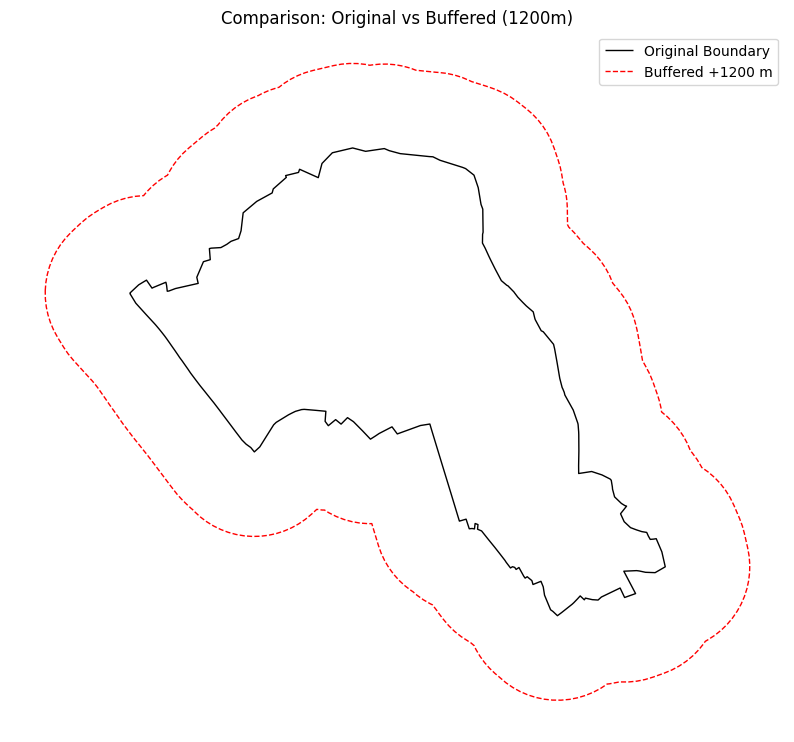

In [ ]:
merged_geometry_lsoa = london_gdf_centroids.unary_union
exterior = Polygon(merged_geometry_lsoa.exterior)
merged_gdf = gpd.GeoDataFrame(geometry=[exterior], crs=london_gdf_centroids.crs)

buffer_dist = 1200  # （m）

# epsg=27700
gdf_proj = merged_gdf.copy().to_crs(epsg=27700)
gdf_proj['buffered_geom'] = gdf_proj.geometry.buffer(buffer_dist)
# epsg=4326
buffered_gdf = gdf_proj.set_geometry('buffered_geom').to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(10, 10))

gdf_proj.set_geometry('geometry').boundary.plot(
    ax=ax, color='black', linewidth=1, label='Original Boundary')
gdf_proj.set_geometry('buffered_geom').boundary.plot(
    ax=ax, color='red', linewidth=1, linestyle='--',
    label=f'Buffered +{buffer_dist:g} m')

plt.legend()
plt.title(f'Comparison: Original vs Buffered ({buffer_dist:g}m)')
plt.axis('off')
plt.show()

In [ ]:
buffered_london_1200m = (
    gdf_proj
    .set_geometry('buffered_geom')
    .drop(columns=['geometry'], errors='ignore')
)

crime_in_london_1200m = gpd.sjoin(crime_filtered, buffered_london_1200m, predicate='within', how='inner')
crime_in_london_1200m = crime_in_london_1200m.drop(columns='index_right')
crime_in_london_1200m

,geometry,Violence and sexual offences
161383,POINT (529702.01 179860.991),16
161534,POINT (530094.006 179913.959),37
161850,POINT (530890.973 180024.995),11
161878,POINT (529529.988 180000.039),3
161938,POINT (529429.024 180016.051),2
...,...,...
196287,POINT (527819.008 188461.031),1
196839,POINT (526220.026 188558.952),6
197035,POINT (527418.023 188639.995),1
197275,POINT (527737.028 188710.003),13


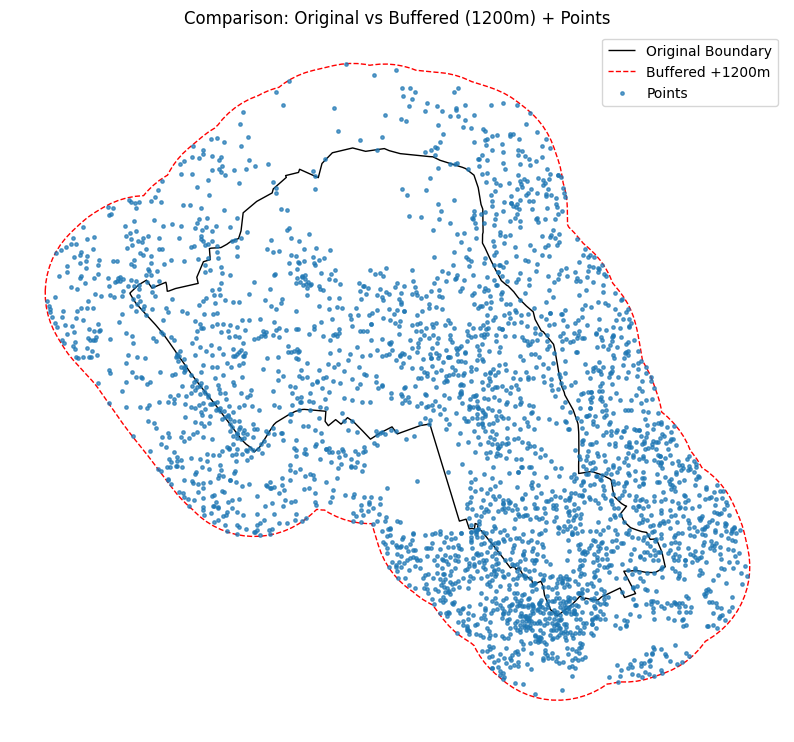

In [ ]:
merged_plot  = merged_gdf.to_crs(27700)
buffered_plot = buffered_london_1200m
points_plot  = crime_in_london_1200m

fig, ax = plt.subplots(figsize=(10, 10))

merged_plot.boundary.plot(ax=ax, color='black', linewidth=1, label='Original Boundary', zorder=1)

buffered_plot.boundary.plot(ax=ax, color='red', linewidth=1, linestyle='--', label='Buffered +1200m', zorder=2)

points_plot.plot(ax=ax, markersize=6, color='tab:blue', alpha=0.7, label='Points', zorder=3)

plt.legend()
plt.title('Comparison: Original vs Buffered (1200m) + Points')
plt.axis('off')
plt.show()

In [ ]:
crime_not_in_london = crime_filtered[~crime_filtered.index.isin(crime_in_london_1200m.index)]
crime_not_in_london

,geometry,Violence and sexual offences
0,POINT (88039.999 8244.015),2
2,POINT (91518.008 10329.983),1
3,POINT (90463.97 10430.957),1
4,POINT (90790.975 10428.041),1
7,POINT (90295.989 10506.998),1
...,...,...
590377,POINT (399411.991 654394.052),1
590378,POINT (399155.981 654430.049),5
590380,POINT (399378.017 654508.025),4
590381,POINT (399330.011 654704.027),5


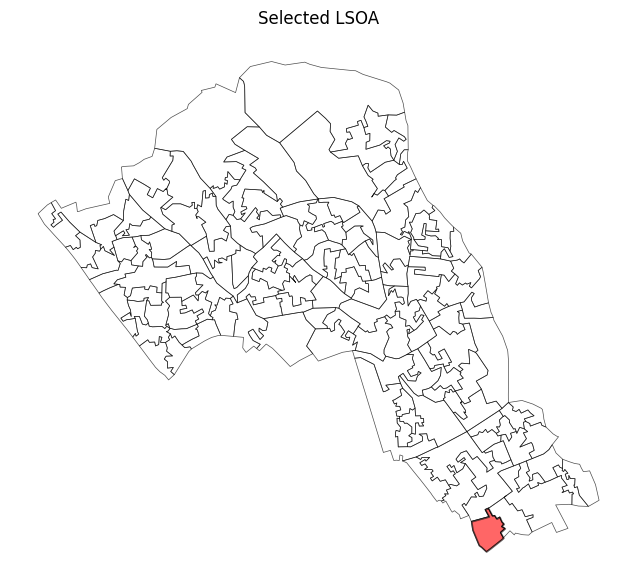

In [ ]:
# 选中目标多边形
target_poly = london_gdf_centroids[london_gdf_centroids['LSOA21CD'] == 'E01000919']

fig, ax = plt.subplots(figsize=(9,7))

# 底图：全伦敦 LSOA 边界（灰色细线）
london_gdf_centroids.boundary.plot(ax=ax, linewidth=0.5, color='black', alpha=0.7)

# 高亮：目标 LSOA（红色填充+黑边）
target_poly.plot(ax=ax, color='red', edgecolor='black', linewidth=1.2, alpha=0.6)

# 如果你还有点图（比如 POIs）：
# points_gdf.plot(ax=ax, markersize=3, alpha=0.5)

ax.set_axis_off()
ax.set_title(f'Selected LSOA', pad=10)
plt.show()

In [ ]:
london_first_buffer = merged_road_buffer.loc[
    merged_road_buffer['LSOA21CD'] == 'E01000919', 'geometry'
].iloc[0]

selected_centroid = london_gdf_centroids.loc[
    london_gdf_centroids['LSOA21CD'] == 'E01000919', 'pop_centroid'
].iloc[0]

selected_centroid_gdf = gpd.GeoDataFrame(
    {'LSOA21CD': ['E01000919']},
    geometry=[selected_centroid],
    crs=london_gdf_centroids.crs
)

def remove_holes(g):
    if g.is_empty:
        return g
    if g.geom_type == 'Polygon':
        return Polygon(g.exterior)
    if g.geom_type == 'MultiPolygon':
        parts = [Polygon(p.exterior) for p in g.geoms if not p.is_empty]
        return MultiPolygon(parts)
    return g
geom_no_holes = remove_holes(london_first_buffer)
london_gdf_buffer = gpd.GeoDataFrame({'geometry': [geom_no_holes]}, crs=merged_road_buffer.crs)
london_gdf_buffer

,geometry
0,"POLYGON ((529056.2 181234.5, 529055.6 181236.6..."


In [ ]:
london_gdf_crime_in_first_buffer = crime_filtered[crime_filtered.geometry.within(london_gdf_buffer.geometry.iloc[0])]
london_gdf_crime_in_first_buffer

,geometry,Violence and sexual offences
162661,POINT (530183.976 180237.962),4
162914,POINT (530042.035 180294.974),14
162954,POINT (530100.032 180308.031),32
163010,POINT (530011.005 180318.995),9
163051,POINT (530314.022 180338.994),5
...,...,...
170730,POINT (529650.007 182046.014),3
171037,POINT (530225.914 182121.167),4
171050,POINT (530225.982 182123.951),5
171139,POINT (529756.987 182129.977),5


In [ ]:
target_crs = 'EPSG:27700'
def to_target(g):
    if hasattr(g, 'crs') and g.crs and g.crs != target_crs:
        return g.to_crs(target_crs)
    return g

london_gdf_centroids = to_target(london_gdf_centroids)
london_gdf_buffer = to_target(london_gdf_buffer)
buffered_plot = to_target(buffered_plot)
crime_not_in_london = to_target(crime_not_in_london)
crime_in_london_1200m = to_target(crime_in_london_1200m)
london_gdf_crime_in_first_buffer = to_target(london_gdf_crime_in_first_buffer)
london_first_buffer = to_target(london_first_buffer)
selected_centroid_gdf = to_target(selected_centroid_gdf)

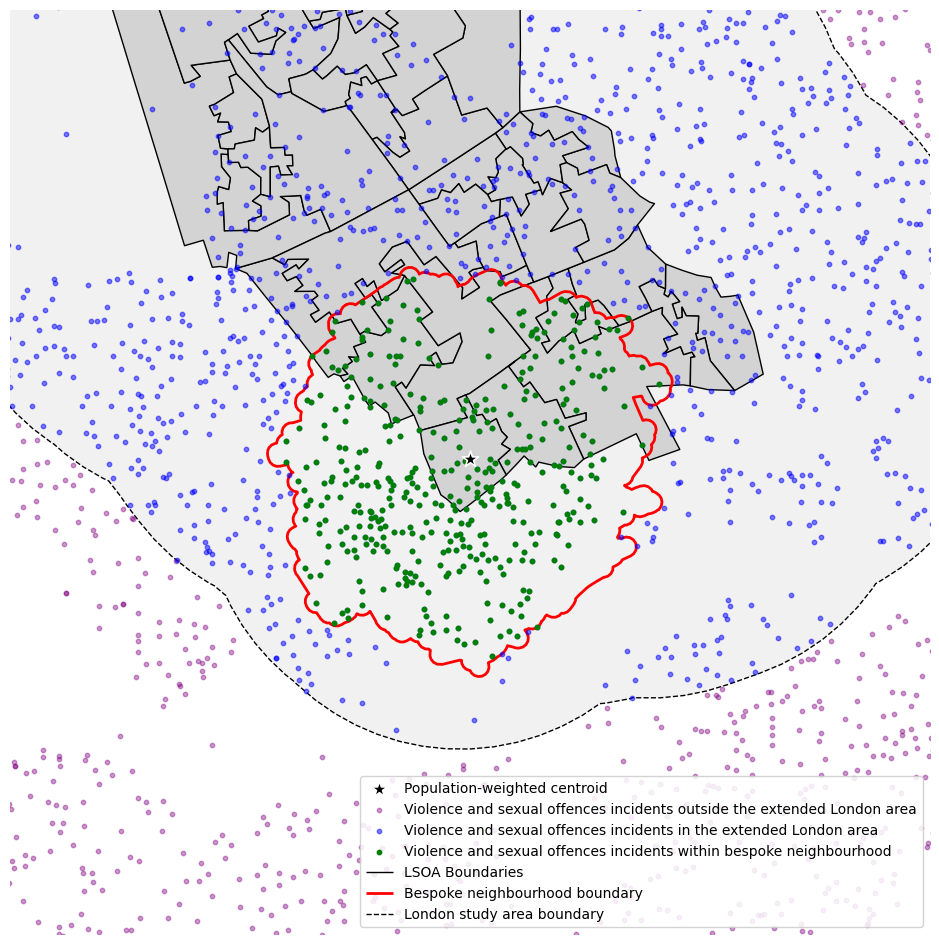

In [ ]:
london_minx, london_miny, london_maxx, london_maxy = london_first_buffer.bounds

fig, ax = plt.subplots(figsize=(12, 12))

ax.scatter(selected_centroid.x, selected_centroid.y, marker='*', s=150, c='black', edgecolors='white', linewidths=1.2, zorder=100, label='Population-weighted centroid')

crime_not_in_london.plot(ax=ax, color='purple', markersize=10, alpha=0.4, label='Violence and sexual offences incidents outside the extended London area', zorder=10)

crime_in_london_1200m.plot(ax=ax, color='blue', markersize=10, alpha=0.5, label='Violence and sexual offences incidents in the extended London area', zorder=11)

london_gdf_crime_in_first_buffer.plot(ax=ax, color='green', markersize=10, label='Violence and sexual offences incidents within bespoke neighbourhood', zorder=12)

london_gdf_centroids.boundary.plot(ax=ax, edgecolor='black', facecolor='lightgray', linewidth=1, label='LSOA Boundaries')

london_gdf_buffer.boundary.plot(ax=ax, color='red', linewidth=2, label='Bespoke neighbourhood boundary')

buffered_plot.plot(ax=ax, facecolor='lightgray', alpha=0.3, edgecolor='none', zorder=0)
buffered_plot.boundary.plot(ax=ax, color='black', linewidth=1, linestyle='--', label='London study area boundary', zorder=2)

buffer_margin = 1300
ax.set_xlim(london_minx - buffer_margin, london_maxx + buffer_margin)
ax.set_ylim(london_miny - buffer_margin, london_maxy + buffer_margin)

leg = ax.legend(loc='lower right', frameon=True,
                facecolor='white',
                framealpha=0.85)
leg.set_zorder(1000)

ax.set_axis_off()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)

plt.show()

# 4 crime

In [ ]:
total_crime_1200m = crime_in_london_1200m[crime_type].sum()
total_crime_1200m

np.int64(22185)

In [ ]:
bn = merged_road_buffer[['LSOA21CD', 'LSOA21NM', 'geometry']].copy()
bn = bn[bn.geometry.notna()].to_crs(27700)
bn['geometry'] = bn.geometry.apply(remove_holes)

In [ ]:
joined = gpd.sjoin(
    crime_in_london_1200m[[crime_type, 'geometry']],
    bn[['LSOA21CD', 'geometry']],
    predicate='intersects', how='inner'
)

counts = (joined.groupby('LSOA21CD')
                .agg(**{crime_type: (crime_type, 'sum'),
                        'Crime_Point_Count': (crime_type, 'size')})
                .reset_index())

crime_df = (bn[['LSOA21CD', 'LSOA21NM']]
              .merge(counts, on='LSOA21CD', how='left')
              .fillna({crime_type: 0, 'Crime_Point_Count': 0}))
crime_df[[crime_type, 'Crime_Point_Count']] = crime_df[[crime_type, 'Crime_Point_Count']].astype(int)

In [ ]:
crime_probability = crime_df.copy()
crime_probability['V_probability'] = crime_probability[crime_type] / total_crime_1200m
crime_probability = crime_probability.drop(columns=['Crime_Point_Count'])   # 案件数这一列先别删
crime_probability

,LSOA21CD,LSOA21NM,Violence and sexual offences,V_probability
0,E01000842,Camden 011A,606,0.027316
1,E01000843,Camden 014A,684,0.030832
2,E01000844,Camden 011B,463,0.020870
3,E01000845,Camden 014B,657,0.029615
4,E01000846,Camden 014C,489,0.022042
...,...,...,...,...
125,E01035708,Camden 022F,1141,0.051431
126,E01035709,Camden 022G,1561,0.070363
127,E01035710,Camden 023F,1075,0.048456
128,E01035711,Camden 026E,1897,0.085508


# 5 ethnic

In [ ]:
merged_London = pd.read_csv('/content/drive/MyDrive/RQ2/github/Camden_data_ethnic.csv')
merged_London

,LSOA21CD,geometry,Does not apply,"Asian, Asian British or Asian Welsh: Bangladeshi","Asian, Asian British or Asian Welsh: Chinese","Asian, Asian British or Asian Welsh: Indian","Asian, Asian British or Asian Welsh: Pakistani","Asian, Asian British or Asian Welsh: Other Asian","Black, Black British, Black Welsh, Caribbean or African: African","Black, Black British, Black Welsh, Caribbean or African: Caribbean",...,Mixed or Multiple ethnic groups: White and Black Caribbean,Mixed or Multiple ethnic groups: Other Mixed or Multiple ethnic groups,"White: English, Welsh, Scottish, Northern Irish or British",White: Irish,White: Gypsy or Irish Traveller,White: Roma,White: Other White,Other ethnic group: Arab,Other ethnic group: Any other ethnic group,Total
0,E01000842,POLYGON ((-0.1652616169351343 51.5472934884195...,0.0,3.0,38.0,49.0,7.0,58.0,27.0,6.0,...,11.0,31.0,532.0,42.0,0.0,7.0,482.0,12.0,90.0,1432.0
1,E01000843,POLYGON ((-0.1617563917975289 51.5486922324688...,0.0,2.0,36.0,32.0,5.0,36.0,19.0,6.0,...,6.0,31.0,480.0,25.0,0.0,1.0,395.0,11.0,66.0,1196.0
2,E01000844,POLYGON ((-0.1720143919421989 51.5465723219166...,0.0,10.0,42.0,98.0,26.0,55.0,29.0,5.0,...,11.0,47.0,520.0,25.0,0.0,13.0,578.0,20.0,90.0,1629.0
3,E01000845,POLYGON ((-0.1602718759969901 51.5460999915509...,0.0,29.0,41.0,55.0,10.0,54.0,31.0,15.0,...,14.0,44.0,623.0,20.0,0.0,4.0,436.0,16.0,64.0,1502.0
4,E01000846,POLYGON ((-0.1649705457065988 51.5448123031397...,0.0,85.0,26.0,28.0,21.0,62.0,257.0,17.0,...,10.0,21.0,398.0,34.0,0.0,10.0,291.0,43.0,104.0,1451.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,E01035708,POLYGON ((-0.1310642508086043 51.5421179152494...,0.0,77.0,243.0,110.0,64.0,128.0,183.0,22.0,...,21.0,60.0,451.0,27.0,1.0,7.0,321.0,48.0,99.0,1952.0
126,E01035709,POLYGON ((-0.1285155422958819 51.5367897145876...,0.0,387.0,52.0,31.0,2.0,68.0,203.0,20.0,...,28.0,37.0,353.0,46.0,0.0,12.0,139.0,28.0,70.0,1538.0
127,E01035710,POLYGON ((-0.1409267961682489 51.5321533115339...,0.0,512.0,181.0,59.0,41.0,113.0,311.0,29.0,...,41.0,49.0,536.0,42.0,4.0,15.0,346.0,56.0,141.0,2579.0
128,E01035711,POLYGON ((-0.1287281360634903 51.5254299980488...,0.0,228.0,269.0,134.0,30.0,103.0,136.0,21.0,...,15.0,61.0,684.0,43.0,0.0,9.0,466.0,33.0,90.0,2430.0


In [ ]:
ethnic_columns_London = [col for col in merged_London.columns if col not in ['LSOA21CD', 'geometry']]
ethnic_totals_London = merged_London[ethnic_columns_London].sum()
ethnic_totals_London

,0
Does not apply,0.0
"Asian, Asian British or Asian Welsh: Bangladeshi",14361.0
"Asian, Asian British or Asian Welsh: Chinese",6728.0
"Asian, Asian British or Asian Welsh: Indian",6953.0
"Asian, Asian British or Asian Welsh: Pakistani",1604.0
"Asian, Asian British or Asian Welsh: Other Asian",8390.0
"Black, Black British, Black Welsh, Caribbean or African: African",14189.0
"Black, Black British, Black Welsh, Caribbean or African: Caribbean",2708.0
"Black, Black British, Black Welsh, Caribbean or African: Other Black",2005.0
Mixed or Multiple ethnic groups: White and Asian,4247.0


In [ ]:
london_fraction = merged_London.copy()
for ethnic_London in ethnic_columns_London:
    london_fraction[f'{ethnic_London}_fraction'] = london_fraction[ethnic_London] / ethnic_totals_London[ethnic_London]
ethnic_columns_London2 = [col for col in merged_London.columns if col not in ['LSOA21CD', 'geometry', 'Does not apply']]
columns_to_keep = ["LSOA21CD", "geometry"] + [f"{ethnic}_fraction" for ethnic in ethnic_columns_London2]
london_fraction = london_fraction[columns_to_keep]

london_fraction

,LSOA21CD,geometry,"Asian, Asian British or Asian Welsh: Bangladeshi_fraction","Asian, Asian British or Asian Welsh: Chinese_fraction","Asian, Asian British or Asian Welsh: Indian_fraction","Asian, Asian British or Asian Welsh: Pakistani_fraction","Asian, Asian British or Asian Welsh: Other Asian_fraction","Black, Black British, Black Welsh, Caribbean or African: African_fraction","Black, Black British, Black Welsh, Caribbean or African: Caribbean_fraction","Black, Black British, Black Welsh, Caribbean or African: Other Black_fraction",...,Mixed or Multiple ethnic groups: White and Black Caribbean_fraction,Mixed or Multiple ethnic groups: Other Mixed or Multiple ethnic groups_fraction,"White: English, Welsh, Scottish, Northern Irish or British_fraction",White: Irish_fraction,White: Gypsy or Irish Traveller_fraction,White: Roma_fraction,White: Other White_fraction,Other ethnic group: Arab_fraction,Other ethnic group: Any other ethnic group_fraction,Total_fraction
0,E01000842,POLYGON ((-0.1652616169351343 51.5472934884195...,0.000209,0.005648,0.007047,0.004364,0.006913,0.001903,0.002216,0.001496,...,0.004315,0.006087,0.007156,0.007877,0.000000,0.007136,0.010883,0.002719,0.009199,0.006814
1,E01000843,POLYGON ((-0.1617563917975289 51.5486922324688...,0.000139,0.005351,0.004602,0.003117,0.004291,0.001339,0.002216,0.000000,...,0.002354,0.006087,0.006456,0.004689,0.000000,0.001019,0.008918,0.002493,0.006746,0.005691
2,E01000844,POLYGON ((-0.1720143919421989 51.5465723219166...,0.000696,0.006243,0.014095,0.016209,0.006555,0.002044,0.001846,0.002993,...,0.004315,0.009228,0.006994,0.004689,0.000000,0.013252,0.013050,0.004532,0.009199,0.007751
3,E01000845,POLYGON ((-0.1602718759969901 51.5460999915509...,0.002019,0.006094,0.007910,0.006234,0.006436,0.002185,0.005539,0.002494,...,0.005492,0.008639,0.008380,0.003751,0.000000,0.004077,0.009844,0.003626,0.006541,0.007147
4,E01000846,POLYGON ((-0.1649705457065988 51.5448123031397...,0.005919,0.003864,0.004027,0.013092,0.007390,0.018113,0.006278,0.010973,...,0.003923,0.004123,0.005353,0.006377,0.000000,0.010194,0.006570,0.009744,0.010630,0.006904
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,E01035708,POLYGON ((-0.1310642508086043 51.5421179152494...,0.005362,0.036118,0.015821,0.039900,0.015256,0.012897,0.008124,0.011970,...,0.008239,0.011781,0.006066,0.005064,0.007874,0.007136,0.007248,0.010877,0.010119,0.009288
126,E01035709,POLYGON ((-0.1285155422958819 51.5367897145876...,0.026948,0.007729,0.004459,0.001247,0.008105,0.014307,0.007386,0.010973,...,0.010985,0.007265,0.004748,0.008627,0.000000,0.012232,0.003138,0.006345,0.007155,0.007318
127,E01035710,POLYGON ((-0.1409267961682489 51.5321533115339...,0.035652,0.026902,0.008486,0.025561,0.013468,0.021918,0.010709,0.018953,...,0.016085,0.009621,0.007209,0.007877,0.031496,0.015291,0.007812,0.012690,0.014411,0.012271
128,E01035711,POLYGON ((-0.1287281360634903 51.5254299980488...,0.015876,0.039982,0.019272,0.018703,0.012277,0.009585,0.007755,0.003990,...,0.005885,0.011977,0.009200,0.008065,0.000000,0.009174,0.010522,0.007478,0.009199,0.011562


# 6

## test

In [ ]:
ethnic_column = ['Asian, Asian British or Asian Welsh: Bangladeshi_fraction']

In [ ]:
radii_list = ['1200']

In [ ]:
crime_types = ['Violence and sexual offences']

In [ ]:
crime_dataframes = []
crime_dataframes.append(
    crime_probability[['LSOA21CD', 'V_probability']]
        .rename(columns={'V_probability': radii_list[0]})
)

crime_merged = crime_dataframes[0]
for df in crime_dataframes[1:]:
    crime_merged = crime_merged.merge(df, on='LSOA21CD', how='outer')

ethnic_fraction_df = london_fraction[['LSOA21CD'] + ethnic_column]
final_df = crime_merged.merge(ethnic_fraction_df, on='LSOA21CD', how='inner')

missing_columns = [c for c in radii_list + ethnic_column if c not in final_df.columns]
if missing_columns:
    raise KeyError(f'Missing columns in final_df: {missing_columns}')

ethnic_name = ethnic_column[0]
crime_probability_final_df = final_df.rename(columns={ethnic_name: 'Ethnic_Fraction'})
crime_probability_final_df['Crime_Type'] = crime_types[0]
crime_probability_final_df['Ethnic']     = ethnic_name
crime_probability_final_df = crime_probability_final_df[
    ['LSOA21CD', 'Ethnic', 'Ethnic_Fraction', 'Crime_Type'] + radii_list
]

crime_probability_final_df

,LSOA21CD,Ethnic,Ethnic_Fraction,Crime_Type,1200
0,E01000842,"Asian, Asian British or Asian Welsh: Banglades...",0.000209,Violence and sexual offences,0.027316
1,E01000843,"Asian, Asian British or Asian Welsh: Banglades...",0.000139,Violence and sexual offences,0.030832
2,E01000844,"Asian, Asian British or Asian Welsh: Banglades...",0.000696,Violence and sexual offences,0.020870
3,E01000845,"Asian, Asian British or Asian Welsh: Banglades...",0.002019,Violence and sexual offences,0.029615
4,E01000846,"Asian, Asian British or Asian Welsh: Banglades...",0.005919,Violence and sexual offences,0.022042
...,...,...,...,...,...
125,E01035708,"Asian, Asian British or Asian Welsh: Banglades...",0.005362,Violence and sexual offences,0.051431
126,E01035709,"Asian, Asian British or Asian Welsh: Banglades...",0.026948,Violence and sexual offences,0.070363
127,E01035710,"Asian, Asian British or Asian Welsh: Banglades...",0.035652,Violence and sexual offences,0.048456
128,E01035711,"Asian, Asian British or Asian Welsh: Banglades...",0.015876,Violence and sexual offences,0.085508


In [ ]:
crime_probability_final_df2 = crime_probability_final_df.copy()
for buffer in radii_list:
    crime_probability_final_df2[f"Weighted_{buffer}"] = crime_probability_final_df[buffer] * crime_probability_final_df["Ethnic_Fraction"]
crime_probability_final_df2

,LSOA21CD,Ethnic,Ethnic_Fraction,Crime_Type,1200,Weighted_1200
0,E01000842,"Asian, Asian British or Asian Welsh: Banglades...",0.000209,Violence and sexual offences,0.027316,0.000006
1,E01000843,"Asian, Asian British or Asian Welsh: Banglades...",0.000139,Violence and sexual offences,0.030832,0.000004
2,E01000844,"Asian, Asian British or Asian Welsh: Banglades...",0.000696,Violence and sexual offences,0.020870,0.000015
3,E01000845,"Asian, Asian British or Asian Welsh: Banglades...",0.002019,Violence and sexual offences,0.029615,0.000060
4,E01000846,"Asian, Asian British or Asian Welsh: Banglades...",0.005919,Violence and sexual offences,0.022042,0.000130
...,...,...,...,...,...,...
125,E01035708,"Asian, Asian British or Asian Welsh: Banglades...",0.005362,Violence and sexual offences,0.051431,0.000276
126,E01035709,"Asian, Asian British or Asian Welsh: Banglades...",0.026948,Violence and sexual offences,0.070363,0.001896
127,E01035710,"Asian, Asian British or Asian Welsh: Banglades...",0.035652,Violence and sexual offences,0.048456,0.001728
128,E01035711,"Asian, Asian British or Asian Welsh: Banglades...",0.015876,Violence and sexual offences,0.085508,0.001358


In [ ]:
crime_probability_final_df2["Weighted_1200"].sum()

np.float64(0.05988801558047373)

## all

In [ ]:
ethnic_column = [col for col in london_fraction.columns if col not in ['LSOA21CD', 'Does not apply_fraction', 'geometry']]
ethnic_column

['Asian, Asian British or Asian Welsh: Bangladeshi_fraction',
 'Asian, Asian British or Asian Welsh: Chinese_fraction',
 'Asian, Asian British or Asian Welsh: Indian_fraction',
 'Asian, Asian British or Asian Welsh: Pakistani_fraction',
 'Asian, Asian British or Asian Welsh: Other Asian_fraction',
 'Black, Black British, Black Welsh, Caribbean or African: African_fraction',
 'Black, Black British, Black Welsh, Caribbean or African: Caribbean_fraction',
 'Black, Black British, Black Welsh, Caribbean or African: Other Black_fraction',
 'Mixed or Multiple ethnic groups: White and Asian_fraction',
 'Mixed or Multiple ethnic groups: White and Black African_fraction',
 'Mixed or Multiple ethnic groups: White and Black Caribbean_fraction',
 'Mixed or Multiple ethnic groups: Other Mixed or Multiple ethnic groups_fraction',
 'White: English, Welsh, Scottish, Northern Irish or British_fraction',
 'White: Irish_fraction',
 'White: Gypsy or Irish Traveller_fraction',
 'White: Roma_fraction',
 'Whi

In [ ]:
ethnic_column = [col for col in london_fraction.columns if col not in ['LSOA21CD', 'Does not apply_fraction', 'geometry']]

crime_inputs = {'1200': (crime_df, total_crime_1200m)}

crime_dataframes2 = []
for radii in radii_list:
    counts_df, total = crime_inputs[radii]
    r = counts_df[['LSOA21CD']].copy()
    r[radii] = counts_df[crime_types[0]] / total
    crime_dataframes2.append(r)

crime_merged = crime_dataframes2[0]
for df in crime_dataframes2[1:]:
    crime_merged = crime_merged.merge(df, on='LSOA21CD', how='outer')

final_df = crime_merged.merge(london_fraction[['LSOA21CD'] + ethnic_column], on='LSOA21CD', how='inner')

missing_columns = [c for c in radii_list + ethnic_column if c not in final_df.columns]
if missing_columns:
    raise KeyError(f'Missing columns in final_df: {missing_columns}')

crime_probability_final_df3 = final_df.melt(id_vars=['LSOA21CD'] + radii_list, value_vars=ethnic_column, var_name='Ethnic', value_name='Ethnic_Fraction')
crime_probability_final_df3['Crime_Type'] = crime_types[0]
crime_probability_final_df3 = crime_probability_final_df3[['LSOA21CD', 'Ethnic', 'Ethnic_Fraction', 'Crime_Type'] + radii_list]
crime_probability_final_df3

,LSOA21CD,Ethnic,Ethnic_Fraction,Crime_Type,1200
0,E01000842,"Asian, Asian British or Asian Welsh: Banglades...",0.000209,Violence and sexual offences,0.027316
1,E01000843,"Asian, Asian British or Asian Welsh: Banglades...",0.000139,Violence and sexual offences,0.030832
2,E01000844,"Asian, Asian British or Asian Welsh: Banglades...",0.000696,Violence and sexual offences,0.020870
3,E01000845,"Asian, Asian British or Asian Welsh: Banglades...",0.002019,Violence and sexual offences,0.029615
4,E01000846,"Asian, Asian British or Asian Welsh: Banglades...",0.005919,Violence and sexual offences,0.022042
...,...,...,...,...,...
2595,E01035708,Total_fraction,0.009288,Violence and sexual offences,0.051431
2596,E01035709,Total_fraction,0.007318,Violence and sexual offences,0.070363
2597,E01035710,Total_fraction,0.012271,Violence and sexual offences,0.048456
2598,E01035711,Total_fraction,0.011562,Violence and sexual offences,0.085508


In [ ]:
crime_probability_final_df4 = crime_probability_final_df3.copy()
for buffer in radii_list:
    crime_probability_final_df4[buffer] = crime_probability_final_df3[buffer] * crime_probability_final_df3["Ethnic_Fraction"]
crime_probability_final_df4

,LSOA21CD,Ethnic,Ethnic_Fraction,Crime_Type,1200
0,E01000842,"Asian, Asian British or Asian Welsh: Banglades...",0.000209,Violence and sexual offences,0.000006
1,E01000843,"Asian, Asian British or Asian Welsh: Banglades...",0.000139,Violence and sexual offences,0.000004
2,E01000844,"Asian, Asian British or Asian Welsh: Banglades...",0.000696,Violence and sexual offences,0.000015
3,E01000845,"Asian, Asian British or Asian Welsh: Banglades...",0.002019,Violence and sexual offences,0.000060
4,E01000846,"Asian, Asian British or Asian Welsh: Banglades...",0.005919,Violence and sexual offences,0.000130
...,...,...,...,...,...
2595,E01035708,Total_fraction,0.009288,Violence and sexual offences,0.000478
2596,E01035709,Total_fraction,0.007318,Violence and sexual offences,0.000515
2597,E01035710,Total_fraction,0.012271,Violence and sexual offences,0.000595
2598,E01035711,Total_fraction,0.011562,Violence and sexual offences,0.000989


In [ ]:
weighted_crime_probability_filtered = (crime_probability_final_df4.groupby("Ethnic")[[buffer]].sum().reindex(ethnic_column))
weighted_crime_probability_filtered

,1200
Ethnic,
"Asian, Asian British or Asian Welsh: Bangladeshi_fraction",0.059888
"Asian, Asian British or Asian Welsh: Chinese_fraction",0.062351
"Asian, Asian British or Asian Welsh: Indian_fraction",0.045107
"Asian, Asian British or Asian Welsh: Pakistani_fraction",0.047148
"Asian, Asian British or Asian Welsh: Other Asian_fraction",0.048868
"Black, Black British, Black Welsh, Caribbean or African: African_fraction",0.051657
"Black, Black British, Black Welsh, Caribbean or African: Caribbean_fraction",0.049486
"Black, Black British, Black Welsh, Caribbean or African: Other Black_fraction",0.050041
Mixed or Multiple ethnic groups: White and Asian_fraction,0.045994


/tmp/ipykernel_1802/2856565669.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=series.values, y=series.index, orient='h', ax=ax, palette=palette)


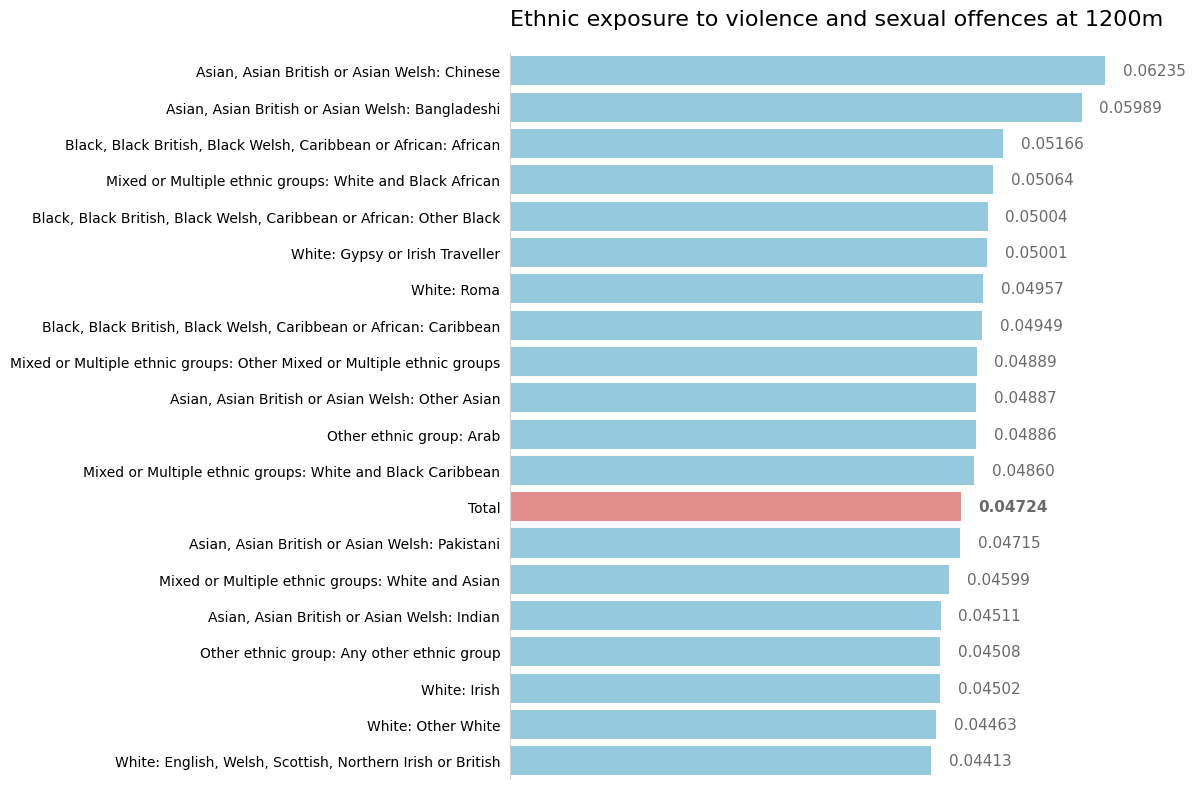

In [ ]:
series = weighted_crime_probability_filtered['1200'].sort_values(ascending=False)

series.index = series.index.str.replace('_fraction', '', regex=False)

fig, ax = plt.subplots(figsize=(12, 8))

palette = ['lightcoral' if 'Total' in idx else '#87CEEB' for idx in series.index]

sns.barplot(x=series.values, y=series.index, orient='h', ax=ax, palette=palette)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_color('lightgray')

ax.tick_params(left=False, bottom=False, labelbottom=False)

offset = series.max() * 0.03

for i, (value, name) in enumerate(zip(series.values, series.index)):
    font_weight = 'bold' if 'Total' in name else 'normal'
    ax.text(value + offset,
            i,
            f'{value:.5f}',
            va='center',
            ha='left',
            fontsize=11,
            color='dimgray',
            fontweight=font_weight)

ax.set_title(f"Ethnic exposure to violence and sexual offences at {col}m", fontsize=16, pad=20, loc='left')
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.show()